In [ ]:
%pip install pandas numpy scipy

In [13]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('Nursing Home Data/Nursing Home Data_data', encoding='utf-8', sep='\s+')

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
C:\Users\kopan\AppData\Local\Temp\ipykernel_19152\3208384263.py:1: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv('Nursing Home Data/Nursing Home Data_data', encoding='utf-8', sep='\s+')


In [ ]:
df = pd.read_csv('filename.txt', sep='\s+', skiprows=1, 
                 names=['BED', 'MCDAYS', 'TDAYS', 'PCREV', 'NSAL', 'FEXP', 'RURAL'])

In [5]:
df.head()

,BED,MCDAYS,TDAYS,PCREV,NSAL,FEXP,RURAL
0,244,128,385,23521,5230,5334,0
1,59,155,203,9160,2459,493,1
2,120,281,392,21900,6304,6115,0
3,120,291,419,22354,6590,6346,0
4,120,238,363,17421,5362,6225,0


In [10]:
urban = df[df['RURAL'] == 0]
country = df[df['RURAL'] == 1]
print(f'Городских больниц: {urban.shape[0]}')
print(f'Загородных больниц: {country.shape[0]}')

Городских больниц: 18
Загородных больниц: 34


Проверим распределение данных на нормальность. Т.к. обе выборки небольшие (менее 50 наблюдений), то применяем критерий Шапиро-Уилка.

In [17]:
print('Urban:')
for column in ['BED', 'MCDAYS', 'TDAYS', 'PCREV', 'NSAL', 'FEXP']:
    statistic, p_value = stats.shapiro(urban[column])
    if p_value >= 0.05:
        print(f'{column}: нормальное распределение')
    else:
        print(f'{column}: не нормальное распределение')

print()
print('Country:')
for column in ['BED', 'MCDAYS', 'TDAYS', 'PCREV', 'NSAL', 'FEXP']:
    statistic, p_value = stats.shapiro(country[column])
    if p_value >= 0.05:
        print(f'{column}: нормальное распределение')
    else:
        print(f'{column}: не нормальное распределение')

Urban:
BED: не нормальное распределение
MCDAYS: нормальное распределение
TDAYS: нормальное распределение
PCREV: нормальное распределение
NSAL: нормальное распределение
FEXP: не нормальное распределение

Country:
BED: не нормальное распределение
MCDAYS: не нормальное распределение
TDAYS: не нормальное распределение
PCREV: не нормальное распределение
NSAL: нормальное распределение
FEXP: не нормальное распределение


Построим графики распределений различных столбцов для городских и загородных больниц:

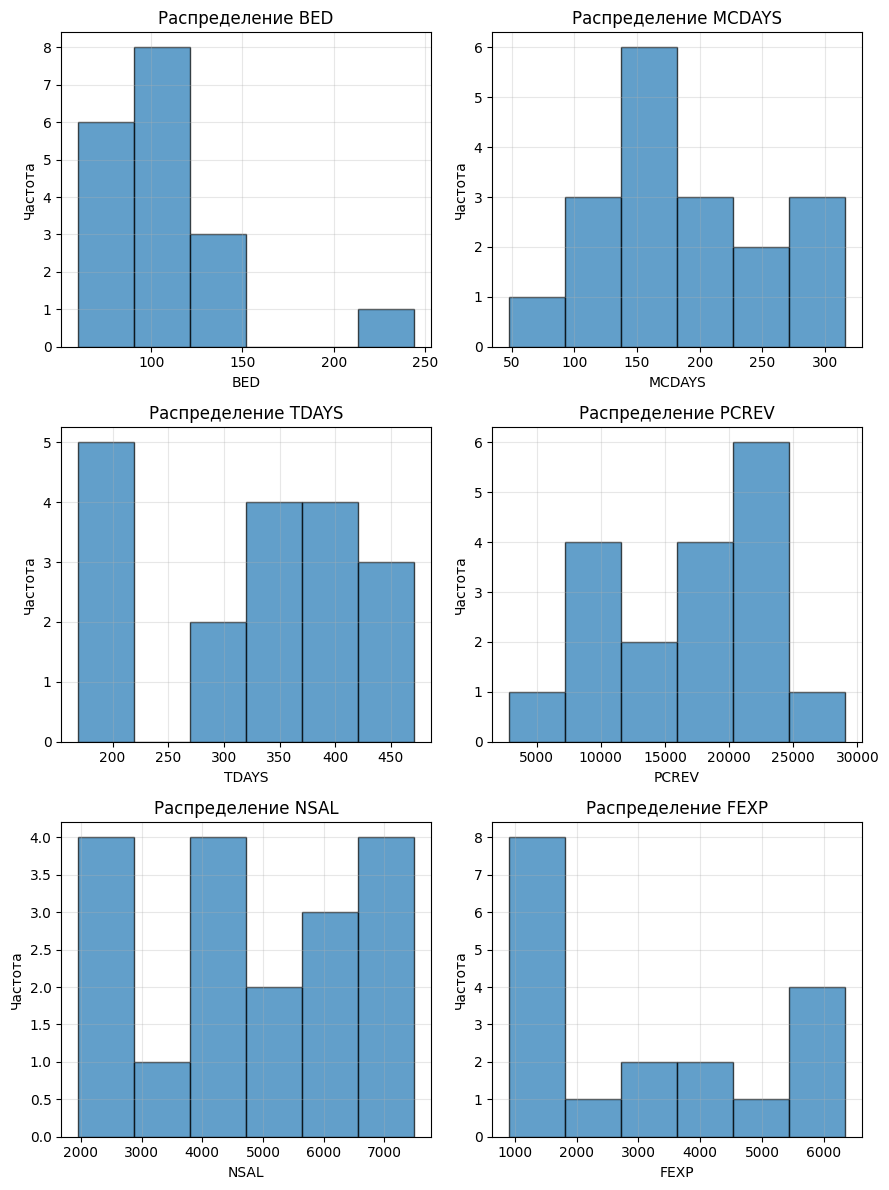

In [26]:
fig, axes = plt.subplots(3, 2, figsize=(9, 12))
columns = ['BED', 'MCDAYS', 'TDAYS', 'PCREV', 'NSAL', 'FEXP']

for i, column in enumerate(columns):
    row = i // 2
    col = i % 2
    n_bins = int(np.ceil(np.log2(len(urban[column])) + 1))
    axes[row, col].hist(urban[column], bins=n_bins, edgecolor='black', alpha=0.7)
    axes[row, col].set_title(f'Распределение {column}')
    axes[row, col].set_xlabel(column)
    axes[row, col].set_ylabel('Частота')
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

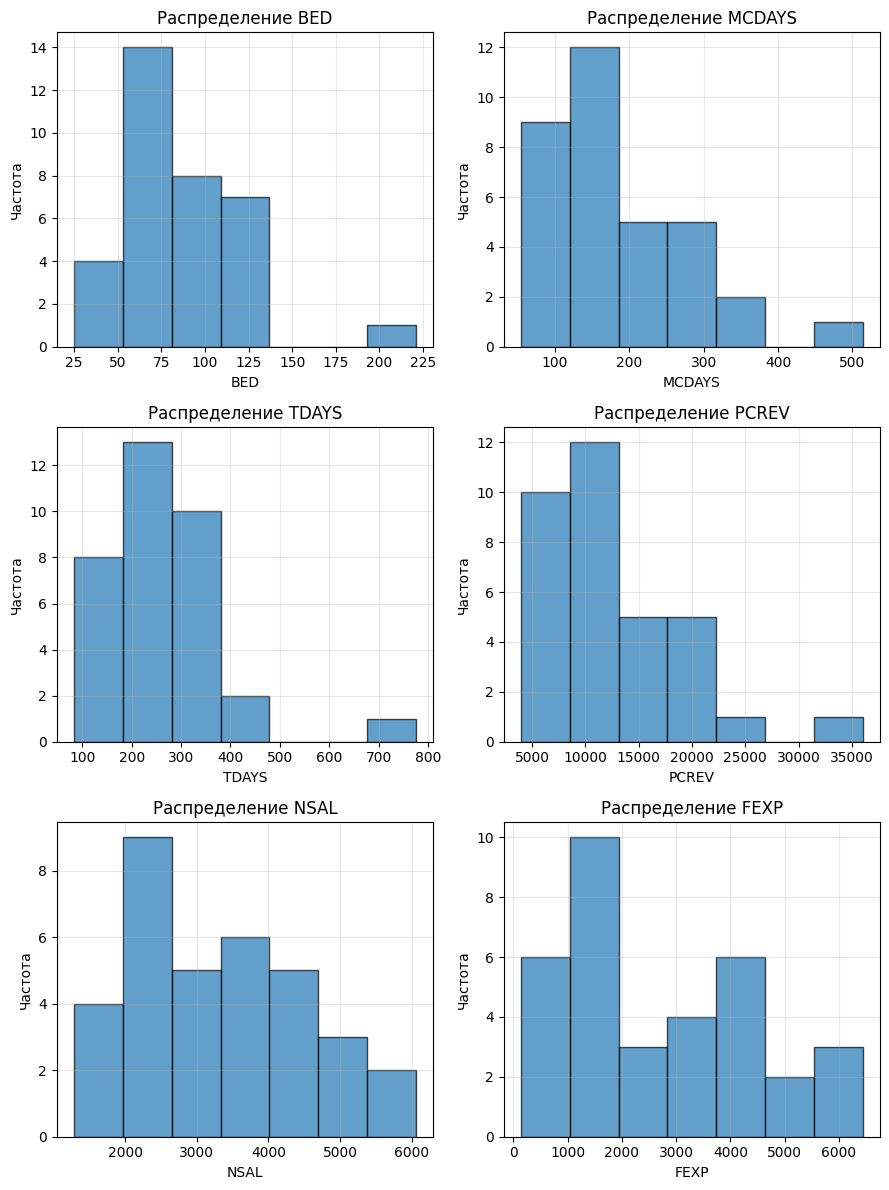

In [27]:
fig, axes = plt.subplots(3, 2, figsize=(9, 12))
columns = ['BED', 'MCDAYS', 'TDAYS', 'PCREV', 'NSAL', 'FEXP']

for i, column in enumerate(columns):
    row = i // 2
    col = i % 2
    n_bins = int(np.ceil(np.log2(len(country[column])) + 1))
    axes[row, col].hist(country[column], bins=n_bins, edgecolor='black', alpha=0.7)
    axes[row, col].set_title(f'Распределение {column}')
    axes[row, col].set_xlabel(column)
    axes[row, col].set_ylabel('Частота')
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Распределения большинства признаков не являются нормальными, да и у тех, которые имеют норм. расп. согласно критерию, визуально распределение тоже не совсем нормальное. Поэтому будем сравнивать медианы.

Для всех признаков:

$H_0$: медианы равны.

$H_1$: медианы не равны.

Воспользуемся критерием Манна-Уитни.

In [28]:
for column in ['BED', 'MCDAYS', 'TDAYS', 'PCREV', 'NSAL', 'FEXP']:
    statistic, p_value = stats.mannwhitneyu(urban[column], country[column], method='exact')
    if p_value < 0.05:
        print(f'{column}: отвергаем гипотезу равенства медиан')
    else:
        print(f'{column}: не отвергаем гипотезу равенства медиан')

BED: отвергаем гипотезу равенства медиан
MCDAYS: не отвергаем гипотезу равенства медиан
TDAYS: отвергаем гипотезу равенства медиан
PCREV: отвергаем гипотезу равенства медиан
NSAL: отвергаем гипотезу равенства медиан
FEXP: не отвергаем гипотезу равенства медиан


Отсюда можно сделать следующие выводы:
* Признаки BED, TDAYS, PCREV, NSAL статистически значимо различаются у городских и загородных больниц
* Признаки MCDAYS и FEXP не различаются статистически значимо у городских и загородных больниц

Построим boxplots для иллюстрации этих различий.

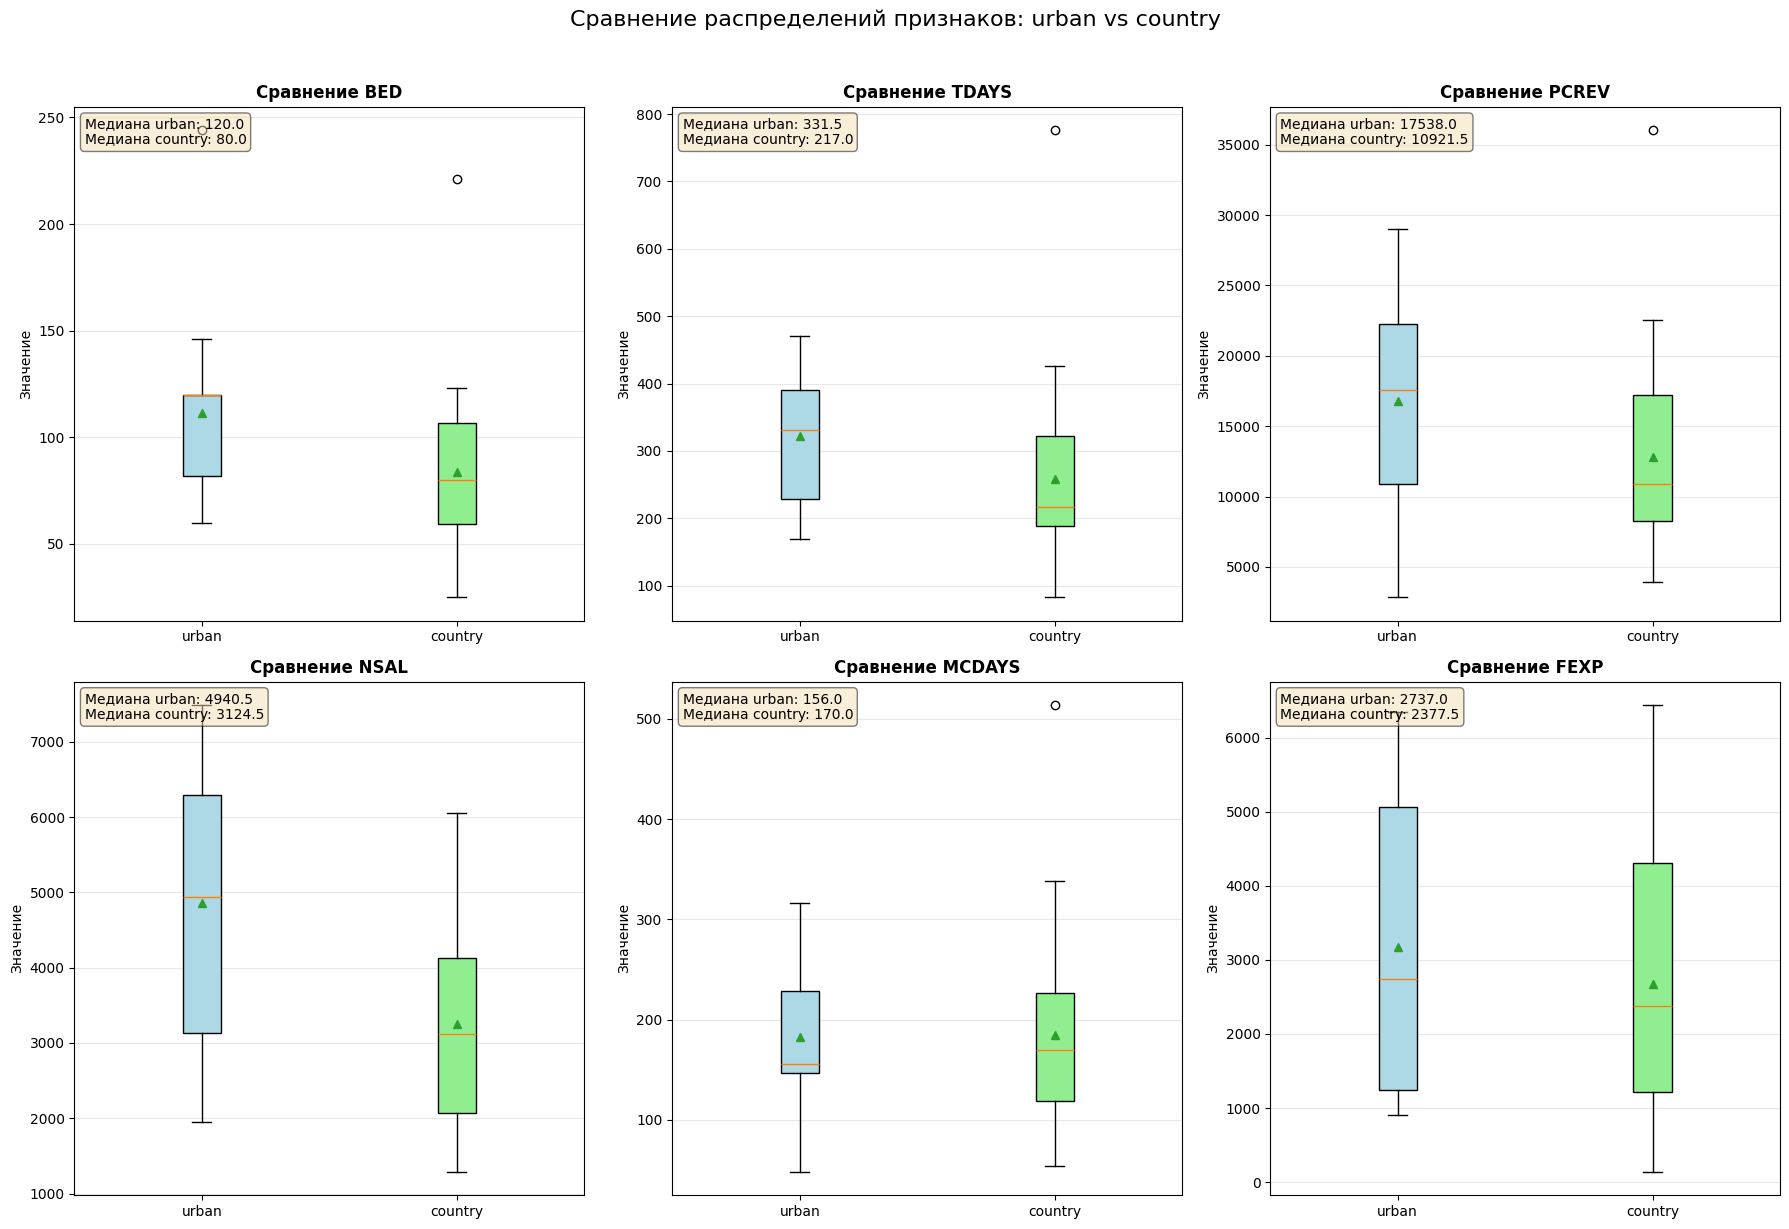

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Сравнение распределений признаков: urban vs country', fontsize=16, y=1.02)
features = ['BED', 'TDAYS', 'PCREV', 'NSAL', 'MCDAYS', 'FEXP']

data_to_plot = []

for i, feature in enumerate(features):
    row = i // 3
    col = i % 3
    data_to_plot = [urban[feature].dropna(), country[feature].dropna()]
    bp = axes[row, col].boxplot(data_to_plot, tick_labels=['urban', 'country'], 
                                patch_artist=True, showmeans=True)
    
    colors = ['lightblue', 'lightgreen']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    axes[row, col].set_title(f'Сравнение {feature}', fontsize=12, fontweight='bold')
    axes[row, col].set_ylabel('Значение', fontsize=10)
    axes[row, col].grid(True, alpha=0.3, axis='y')
    
    urban_median = np.median(urban[feature], keepdims=True)[0]
    country_median = np.median(country[feature], keepdims=True)[0]
    
    axes[row, col].text(0.02, 0.98, f'Медиана urban: {urban_median:.1f}\nМедиана country: {country_median:.1f}', 
                       transform=axes[row, col].transAxes, verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()